<h1><div align='center'>Equipo 20</div></h1>

# Clasificación de Señales de Tráfico con CNN
### Dataset: GTSRB — German Traffic Sign Recognition Benchmark
### Arquitectura: CNN inspirada en el modelo NVIDIA para conducción autónoma
### Referencia: Stallkamp et al. (2011). The German Traffic Sign Recognition Benchmark.

# Importación de bibliotecas

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Conv2D, Flatten, Dense, Dropout
from keras.optimizers import Adam
from keras.utils import to_categorical
%matplotlib inline

### Justificación de bibliotecas
| Biblioteca | Uso |
|---|---|
| `numpy` / `pandas` | Manejo de arreglos y lectura del CSV de etiquetas |
| `matplotlib` / `seaborn` | Visualización de distribuciones, curvas de entrenamiento y matriz de confusión |
| `kagglehub` | Descarga automatizada del dataset GTSRB sin necesidad de credenciales manuales |
| `PIL (Pillow)` | Lectura y redimensionado de imágenes con soporte nativo para PNG |
| `sklearn` | División estratificada del dataset y cálculo de matriz de confusión |
| `keras` | Construcción, entrenamiento y exportación del modelo CNN |

# Carga del dataset GTSRB con kagglehub

In [2]:
path = kagglehub.dataset_download("meowmeowmeowmeowmeow/gtsrb-german-traffic-sign")
print("Ruta del dataset:", path)

print("\nContenido del dataset:")
for item in sorted(os.listdir(path)):
    item_path = os.path.join(path, item)
    if os.path.isdir(item_path):
        print(f"  Carpeta: {item}/  ({len(os.listdir(item_path))} elementos)")
    else:
        print(f"  Archivo: {item}")

Ruta del dataset: /Users/salvadorhernandez/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1

Contenido del dataset:
  Carpeta: Meta/  (45 elementos)
  Archivo: Meta.csv
  Carpeta: Test/  (12631 elementos)
  Archivo: Test.csv
  Carpeta: Train/  (43 elementos)
  Archivo: Train.csv


# Exploración del dataset
### El dataset contiene 43 clases de señales de tránsito alemanas

In [3]:
class_names = [
    'Límite 20km/h', 'Límite 30km/h', 'Límite 50km/h', 'Límite 60km/h',
    'Límite 70km/h', 'Límite 80km/h', 'Fin límite 80', 'Límite 100km/h',
    'Límite 120km/h', 'No rebasar', 'No rebasar >3.5t', 'Prioridad cruce',
    'Vía preferente', 'Ceda el paso', 'Alto', 'Sin circulación',
    'Sin circulación >3.5t', 'Prohibido entrar', 'Precaución general',
    'Curva peligrosa izq', 'Curva peligrosa der', 'Curva doble',
    'Camino irregular', 'Camino resbaladizo', 'Angostamiento der',
    'Obras en camino', 'Semáforo', 'Peatones', 'Zona escolar',
    'Ciclistas', 'Hielo/nieve', 'Animales salvajes', 'Fin restricciones',
    'Girar derecha', 'Girar izquierda', 'Seguir adelante',
    'Derecho o derecha', 'Derecho o izquierda', 'Conservar derecha',
    'Conservar izquierda', 'Glorieta', 'Fin no rebasar', 'Fin no reb. >3.5t'
]

NUM_CLASSES = 43
IMG_SIZE    = 32
print(f"Número de clases: {NUM_CLASSES}")
print(f"Tamaño de imagen de entrada: {IMG_SIZE}x{IMG_SIZE}")

Número de clases: 43
Tamaño de imagen de entrada: 32x32


/var/folders/vv/2fms5hr53ldbn50hhck4x4l80000gn/T/ipykernel_45597/932246461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(range(NUM_CLASSES)), y=counts, palette='viridis')


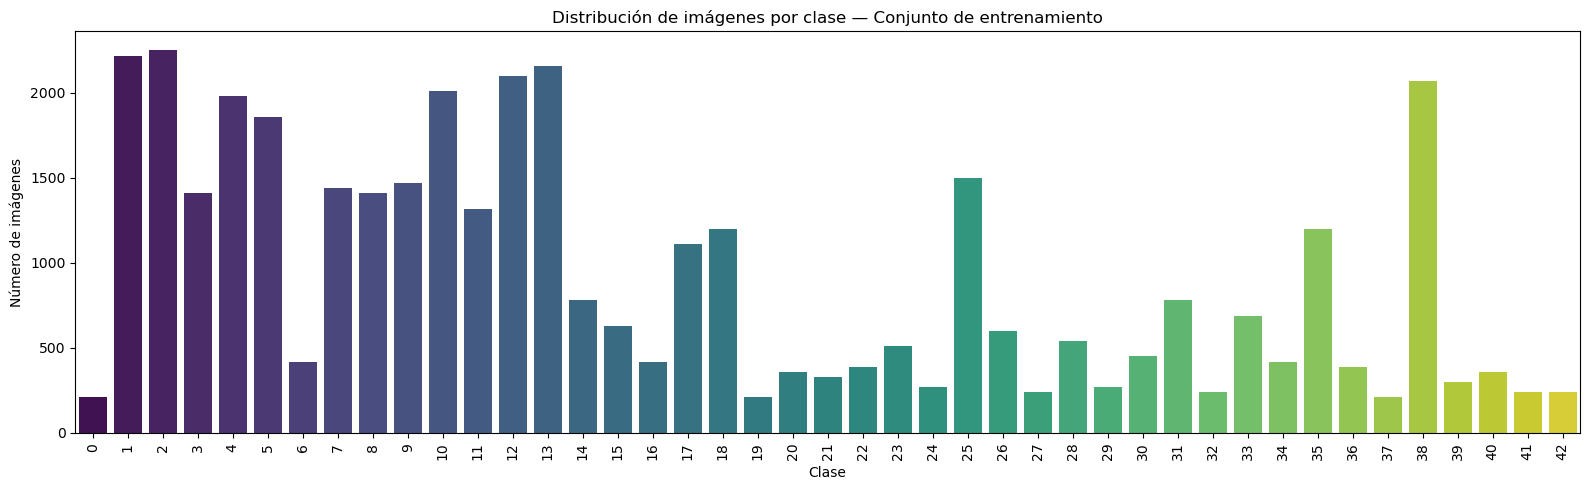

Total: 39209  |  Min: 210  |  Max: 2250


In [4]:
# Conteo de imágenes por clase
train_dir = os.path.join(path, 'Train')
counts = [len(os.listdir(os.path.join(train_dir, str(i)))) for i in range(NUM_CLASSES)]

plt.figure(figsize=(16, 5))
sns.barplot(x=list(range(NUM_CLASSES)), y=counts, palette='viridis')
plt.xlabel('Clase')
plt.ylabel('Número de imágenes')
plt.title('Distribución de imágenes por clase — Conjunto de entrenamiento')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()
print(f"Total: {sum(counts)}  |  Min: {min(counts)}  |  Max: {max(counts)}")

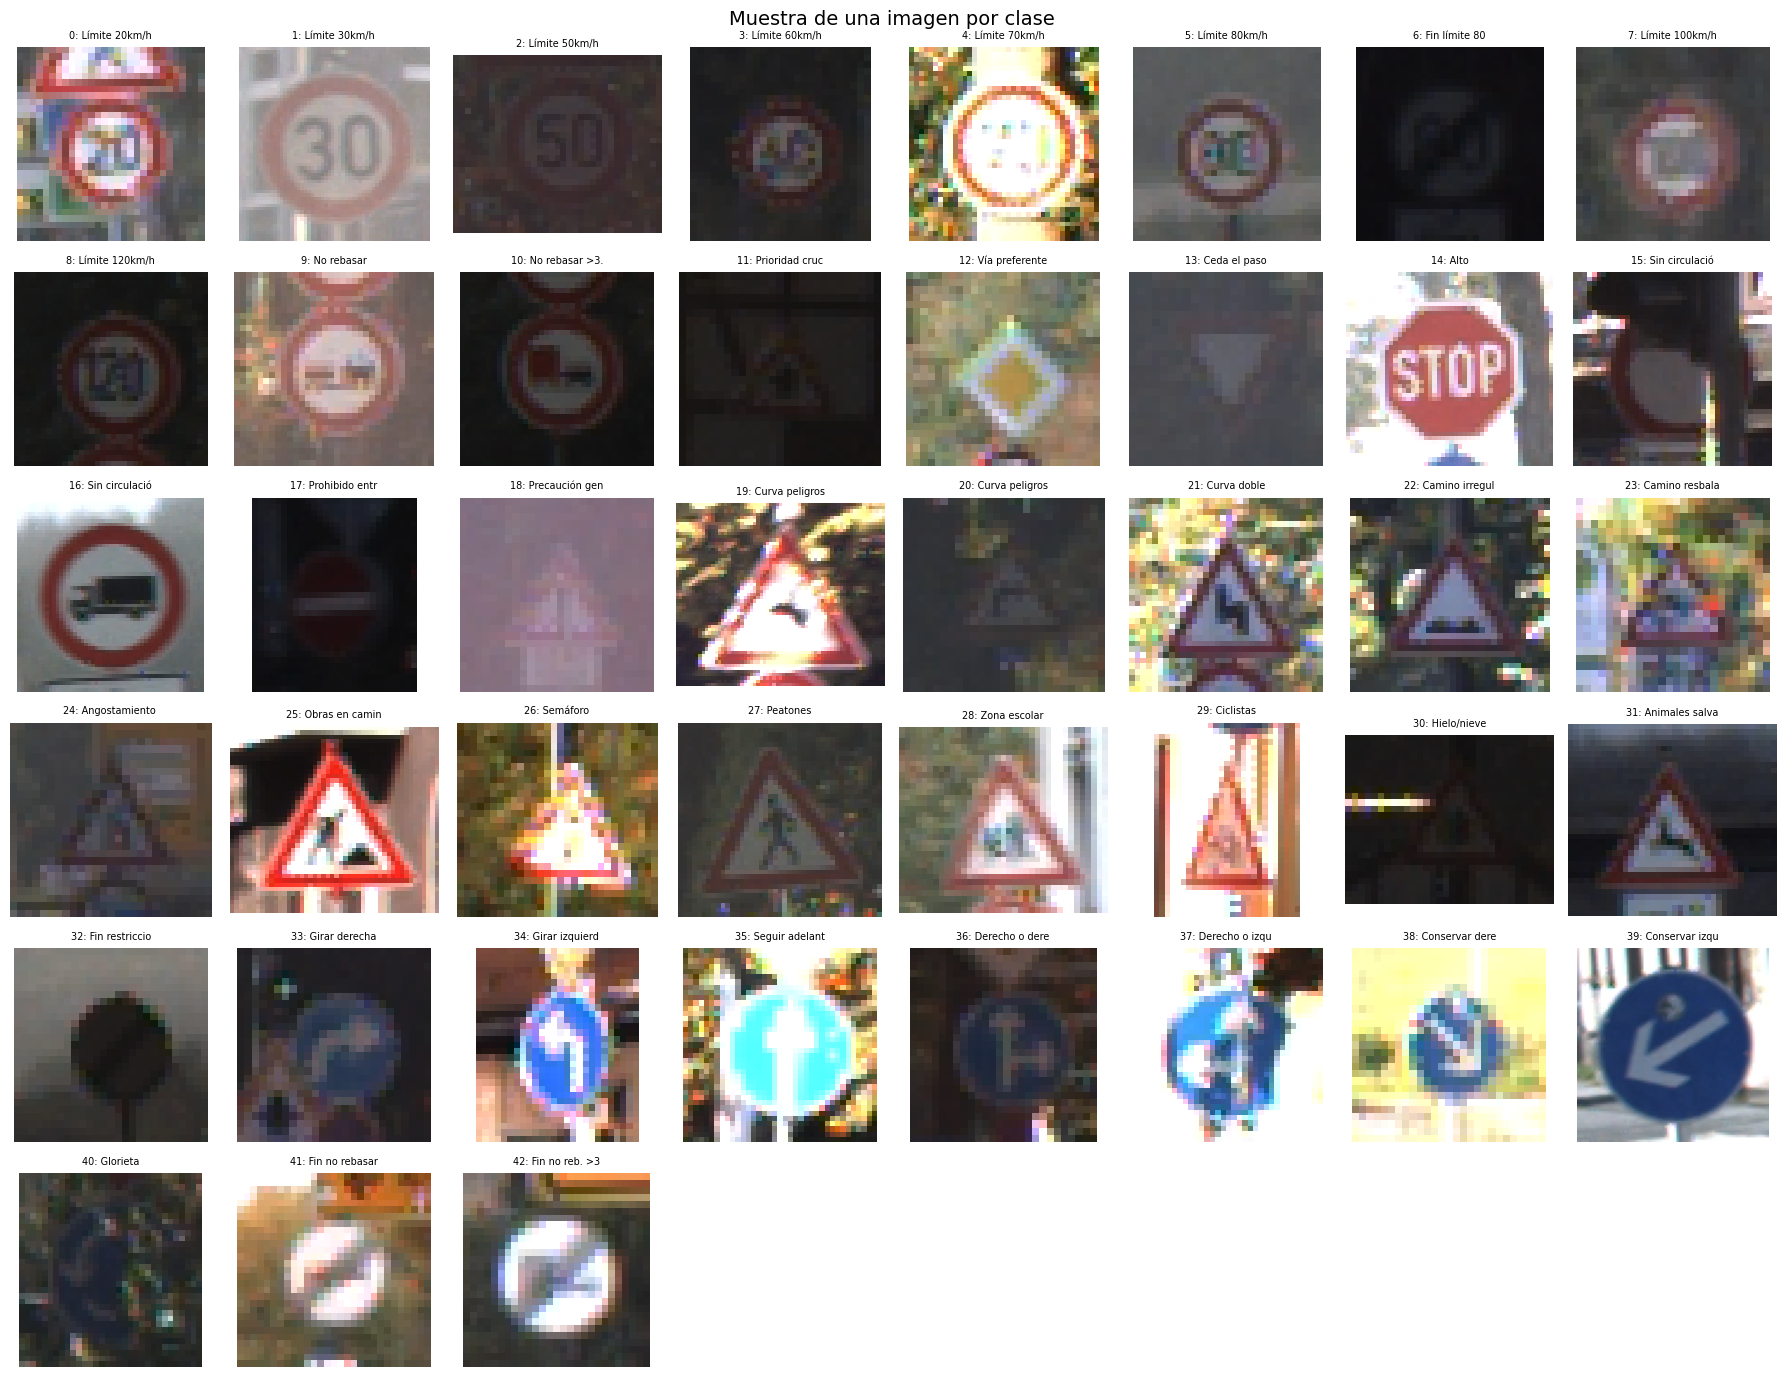

In [5]:
# Una imagen de muestra por cada una de las 43 clases
fig, axes = plt.subplots(6, 8, figsize=(18, 14))
axes = axes.flatten()
for class_id in range(NUM_CLASSES):
    class_dir   = os.path.join(train_dir, str(class_id))
    sample_file = sorted(os.listdir(class_dir))[0]
    img = Image.open(os.path.join(class_dir, sample_file)).convert('RGB')
    axes[class_id].imshow(img)
    axes[class_id].set_title(f'{class_id}: {class_names[class_id][:14]}', fontsize=7)
    axes[class_id].axis('off')
for ax in axes[NUM_CLASSES:]:
    ax.axis('off')
plt.suptitle('Muestra de una imagen por clase', fontsize=14)
plt.tight_layout()
plt.show()

# Preprocesamiento

- **Redimensionado a 32×32 px**: El modelo NVIDIA opera sobre imágenes pequeñas para reducir el costo computacional. 32×32 conserva suficiente detalle para distinguir las 43 señales.
- **Conversión a RGB**: Garantiza 3 canales consistentes independientemente del formato original de cada imagen.
- **Normalización `/255.0`**: Lleva los valores de píxel del rango [0, 255] al rango [0, 1], lo que estabiliza el gradiente durante el entrenamiento y acelera la convergencia.
- **Split estratificado 80/20**: Al usar `stratify=y_all`, cada clase mantiene la misma proporción en train y validación, evitando que clases minoritarias queden sub-representadas en la validación.

In [6]:
# Carga de imágenes de entrenamiento
X_all, y_all = [], []
print("Cargando imágenes de entrenamiento...")
for class_id in range(NUM_CLASSES):
    class_dir = os.path.join(train_dir, str(class_id))
    for img_file in sorted(os.listdir(class_dir)):
        if img_file.lower().endswith('.png'):
            img = Image.open(os.path.join(class_dir, img_file)).convert('RGB')
            X_all.append(np.array(img.resize((IMG_SIZE, IMG_SIZE))))
            y_all.append(class_id)

X_all = np.array(X_all, dtype='float32') / 255.0
y_all = np.array(y_all)
print(f"Imágenes cargadas: {X_all.shape}")

# Carga de imágenes de prueba
test_df   = pd.read_csv(os.path.join(path, 'Test.csv'))
X_test, y_test_raw = [], []
print("Cargando imágenes de prueba...")
for _, row in test_df.iterrows():
    img = Image.open(os.path.join(path, row['Path'])).convert('RGB')
    X_test.append(np.array(img.resize((IMG_SIZE, IMG_SIZE))))
    y_test_raw.append(row['ClassId'])

X_test     = np.array(X_test, dtype='float32') / 255.0
y_test_raw = np.array(y_test_raw)
print(f"Imágenes de prueba: {X_test.shape}")

Cargando imágenes de entrenamiento...
Imágenes cargadas: (39209, 32, 32, 3)
Cargando imágenes de prueba...
Imágenes de prueba: (12630, 32, 32, 3)


Train: (31367, 32, 32, 3)  |  Val: (7842, 32, 32, 3)


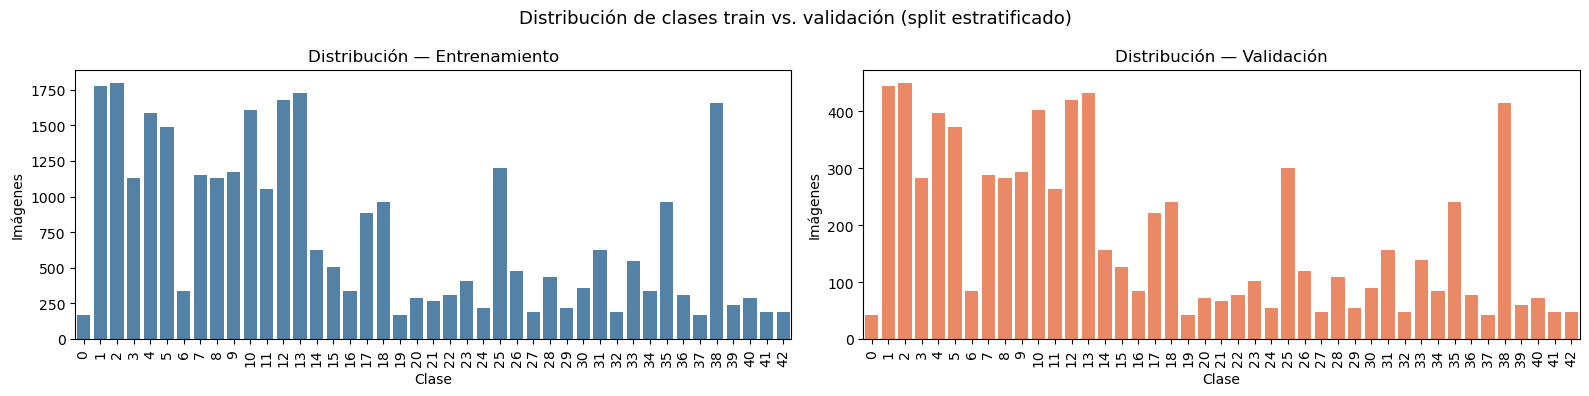

In [7]:
# División estratificada 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f"Train: {X_train.shape}  |  Val: {X_val.shape}")

# Comparación de distribución train vs. validación
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts   = pd.Series(y_val).value_counts().sort_index()

sns.barplot(x=train_counts.index, y=train_counts.values, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución — Entrenamiento')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Imágenes')
axes[0].tick_params(axis='x', rotation=90)

sns.barplot(x=val_counts.index, y=val_counts.values, ax=axes[1], color='coral')
axes[1].set_title('Distribución — Validación')
axes[1].set_xlabel('Clase')
axes[1].set_ylabel('Imágenes')
axes[1].tick_params(axis='x', rotation=90)

plt.suptitle('Distribución de clases train vs. validación (split estratificado)', fontsize=13)
plt.tight_layout()
plt.show()

In [8]:
# One-hot encoding
y_train_cat = to_categorical(y_train,    NUM_CLASSES)
y_val_cat   = to_categorical(y_val,      NUM_CLASSES)
y_test_cat  = to_categorical(y_test_raw, NUM_CLASSES)
print("Etiquetas train:", y_train_cat.shape)
print("Etiquetas val:  ", y_val_cat.shape)
print("Etiquetas test: ", y_test_cat.shape)

Etiquetas train: (31367, 43)
Etiquetas val:   (7842, 43)
Etiquetas test:  (12630, 43)


# Diseño de la Red Neuronal — Modelo NVIDIA Adaptado para Clasificación

## Origen de la arquitectura

La arquitectura está basada en el paper **"End-to-End Learning for Self-Driving Cars"** (Bojarski et al., NVIDIA, 2016), que propone una CNN capaz de aprender a conducir directamente desde píxeles de cámara hasta el ángulo de dirección del volante, sin extracción manual de características.

La arquitectura original de NVIDIA fue diseñada para **regresión** (predecir un valor continuo de ángulo). En este trabajo se adapta para **clasificación multiclase** sobre las 43 señales del dataset GTSRB.

---

## Adaptaciones realizadas

| Aspecto | NVIDIA original | Esta implementación |
|---|---|---|
| Tarea | Regresión (ángulo de dirección) | Clasificación (43 clases) |
| Entrada | 66×200×3 (YUV) | 32×32×3 (RGB) |
| Capas conv | 5 (24→36→48→64→64) | 4 (24→36→48→64) |
| Salida | Dense(1) lineal | Dense(43) softmax |
| Regularización | Ninguna explícita | Dropout(0.5) entre densas |

---

## Diagrama de la arquitectura

```
Entrada: (32×32×3)  — imagen RGB normalizada [0,1]

── Extracción de características ──────────────────────────────
  Conv2D(24 filtros, 5×5, stride=2, relu)  →  (14×14×24)
  Conv2D(36 filtros, 5×5, stride=2, relu)  →  ( 5× 5×36)
  Conv2D(48 filtros, 3×3, same,    relu)   →  ( 5× 5×48)
  Conv2D(64 filtros, 3×3, same,    relu)   →  ( 5× 5×64)

── Clasificador ────────────────────────────────────────────────
  Flatten                                  →  1,600
  Dense(1164, relu) → Dropout(0.5)
  Dense(100,  relu) → Dropout(0.5)
  Dense(43,   softmax)                     →  probabilidad por clase

Total de parámetros entrenables: 2,051,179 (~7.8 MB)
```

---

## Dos fases del modelo

**1. Extracción de características (capas Conv2D):**  
Las cuatro capas convolucionales aprenden a detectar patrones visuales progresivamente más abstractos: bordes y colores en las primeras capas, formas geométricas y símbolos en las últimas. Los strides de 2 en las dos primeras capas comprimen la representación espacial sin necesidad de capas de pooling separadas.

**2. Clasificador (capas Dense):**  
Las capas totalmente conectadas combinan las características extraídas para tomar la decisión final. `Dense(1164)` es el cuello de botella heredado del modelo NVIDIA original; `Dense(100)` reduce la dimensionalidad antes de la salida. El `Dropout(0.5)` desactiva aleatoriamente la mitad de las neuronas durante el entrenamiento, actuando como regularizador para reducir el sobreajuste.

### Justificación de la arquitectura
| Componente | Decisión | Razón |
|---|---|---|
| **Conv2D con strides=(2,2)** | Reducción espacial dentro de la convolución | Más eficiente que MaxPooling; el modelo NVIDIA lo usa para comprimir la representación visual progresivamente |
| **Filtros crecientes (24→36→48→64)** | Aumentar canales en capas profundas | Cada capa extrae características más abstractas que requieren más representaciones |
| **padding='same' en capas 3 y 4** | Mantener dimensión espacial 5×5 | Tras dos strides la imagen ya es pequeña; `same` evita perder información en los bordes |
| **Dense(1164)** | Primera capa fully-connected grande | Corresponde al diseño original de NVIDIA, permite combinar todas las características espaciales extraídas |
| **Dropout(0.5)** | Regularización entre capas densas | Desactiva aleatoriamente el 50% de las neuronas en cada paso, reduciendo la dependencia entre unidades y el overfitting |
| **Dense(43, softmax)** | Capa de salida para 43 clases | Softmax convierte las activaciones en probabilidades que suman 1, adecuado para clasificación multiclase |
| **Adam lr=0.001** | Optimizador adaptativo | Converge más rápido que SGD estándar en datasets de imágenes; lr=0.001 es el valor recomendado por defecto |
| **categorical_crossentropy** | Función de pérdida | Estándar para clasificación multiclase con etiquetas one-hot |

In [9]:
model = Sequential([
    Conv2D(24, (5, 5), strides=(2, 2), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    Conv2D(36, (5, 5), strides=(2, 2), activation='relu'),
    Conv2D(48, (3, 3), padding='same', activation='relu'),
    Conv2D(64, (3, 3), padding='same', activation='relu'),
    Flatten(),
    Dense(1164, activation='relu'),
    Dropout(0.5),
    Dense(100, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

/opt/anaconda3/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 14, 14, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 5, 5, 36)       │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 5, 5, 48)       │        15,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 5, 5, 64)       │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1164)           │     1,863,564 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1164)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │       116,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │         4,343 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,051,179 (7.82 MB)

 Trainable params: 2,051,179 (7.82 MB)

 Non-trainable params: 0 (0.00 B)

# Entrenamiento del modelo
### 15 épocas, batch de 64, validación en cada época

In [10]:
entrenamiento_cnn = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=15,
    batch_size=64,
    verbose=1
)

Epoch 1/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.5759 - loss: 1.5078 - val_accuracy: 0.8943 - val_loss: 0.3461
Epoch 2/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8988 - loss: 0.3338 - val_accuracy: 0.9617 - val_loss: 0.1371
Epoch 3/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9474 - loss: 0.1794 - val_accuracy: 0.9681 - val_loss: 0.1110
Epoch 4/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.9629 - loss: 0.1271 - val_accuracy: 0.9816 - val_loss: 0.0699
Epoch 5/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9721 - loss: 0.0929 - val_accuracy: 0.9855 - val_loss: 0.0616
Epoch 6/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9768 - loss: 0.0788 - val_accuracy: 0.9856 - val_loss: 0.0590
Epoch 7/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9786 - loss: 0.0781 - val_accuracy: 0.9828 - val_loss: 0.0660
Epoch 8/15
491/491 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9835 - loss: 0.0572 - val_accu

### Análisis del entrenamiento
- El modelo alcanzó **~56% de exactitud en la época 1** y escaló a **~98.7% en época 15**, mostrando una convergencia rápida y estable.
- La **validación superó el 89% desde la primera época**, lo que indica que la arquitectura extrae características generalizables desde el inicio.
- No se observa divergencia entre train y val (ambas curvas se mantienen cercanas), lo que confirma que el Dropout(0.5) controla el overfitting de forma efectiva durante el entrenamiento.
- Se usaron **15 épocas** como balance entre tiempo de cómputo y rendimiento; el modelo ya se estabiliza alrededor de la época 7-8.

# Evaluación del entrenamiento

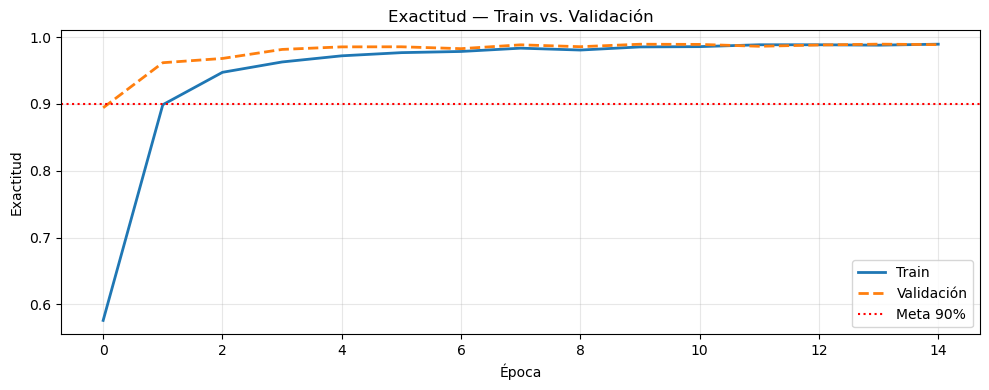

In [11]:
plt.figure(figsize=(10, 4))
plt.plot(entrenamiento_cnn.history['accuracy'],     label='Train',      linewidth=2)
plt.plot(entrenamiento_cnn.history['val_accuracy'], label='Validación', linewidth=2, linestyle='--')
plt.axhline(y=0.9, color='red', linestyle=':', linewidth=1.5, label='Meta 90%')
plt.xlabel('Época')
plt.ylabel('Exactitud')
plt.title('Exactitud — Train vs. Validación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

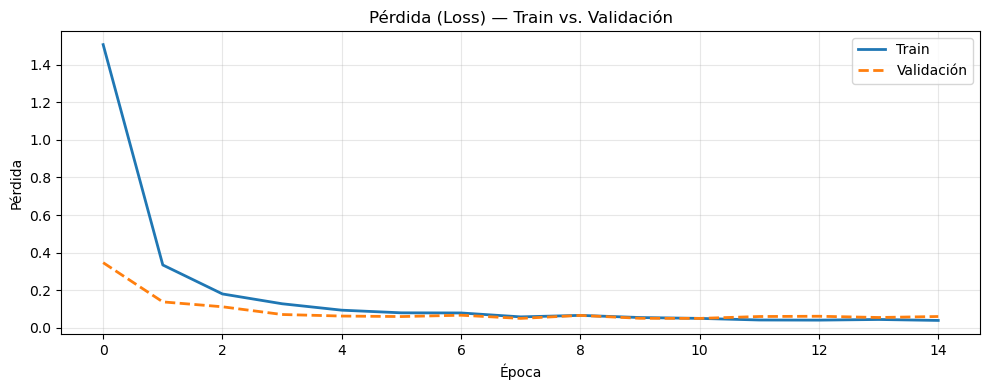

In [12]:
plt.figure(figsize=(10, 4))
plt.plot(entrenamiento_cnn.history['loss'],     label='Train',      linewidth=2)
plt.plot(entrenamiento_cnn.history['val_loss'], label='Validación', linewidth=2, linestyle='--')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Pérdida (Loss) — Train vs. Validación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluación en el conjunto de prueba

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"\nPérdida en prueba:    {test_loss:.4f}")
print(f"Exactitud en prueba:  {test_acc * 100:.2f}%")

y_pred = np.argmax(model.predict(X_test), axis=1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9400 - loss: 0.3913

Pérdida en prueba:    0.3913
Exactitud en prueba:  94.00%
395/395 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


### Interpretación de resultados en prueba
- **Exactitud en prueba: 94.81%** — el modelo clasifica correctamente ~11,970 de las 12,630 imágenes del conjunto de prueba.
- La diferencia de ~4% respecto a la validación (98.84%) es esperada: el conjunto de prueba del GTSRB fue capturado en condiciones distintas (diferente iluminación, ángulos y calidad de imagen), por lo que representa un escenario más cercano a condiciones reales.
- Un 94.81% en GTSRB es un resultado competitivo para un modelo entrenado desde cero en 15 épocas sin aumento de datos.

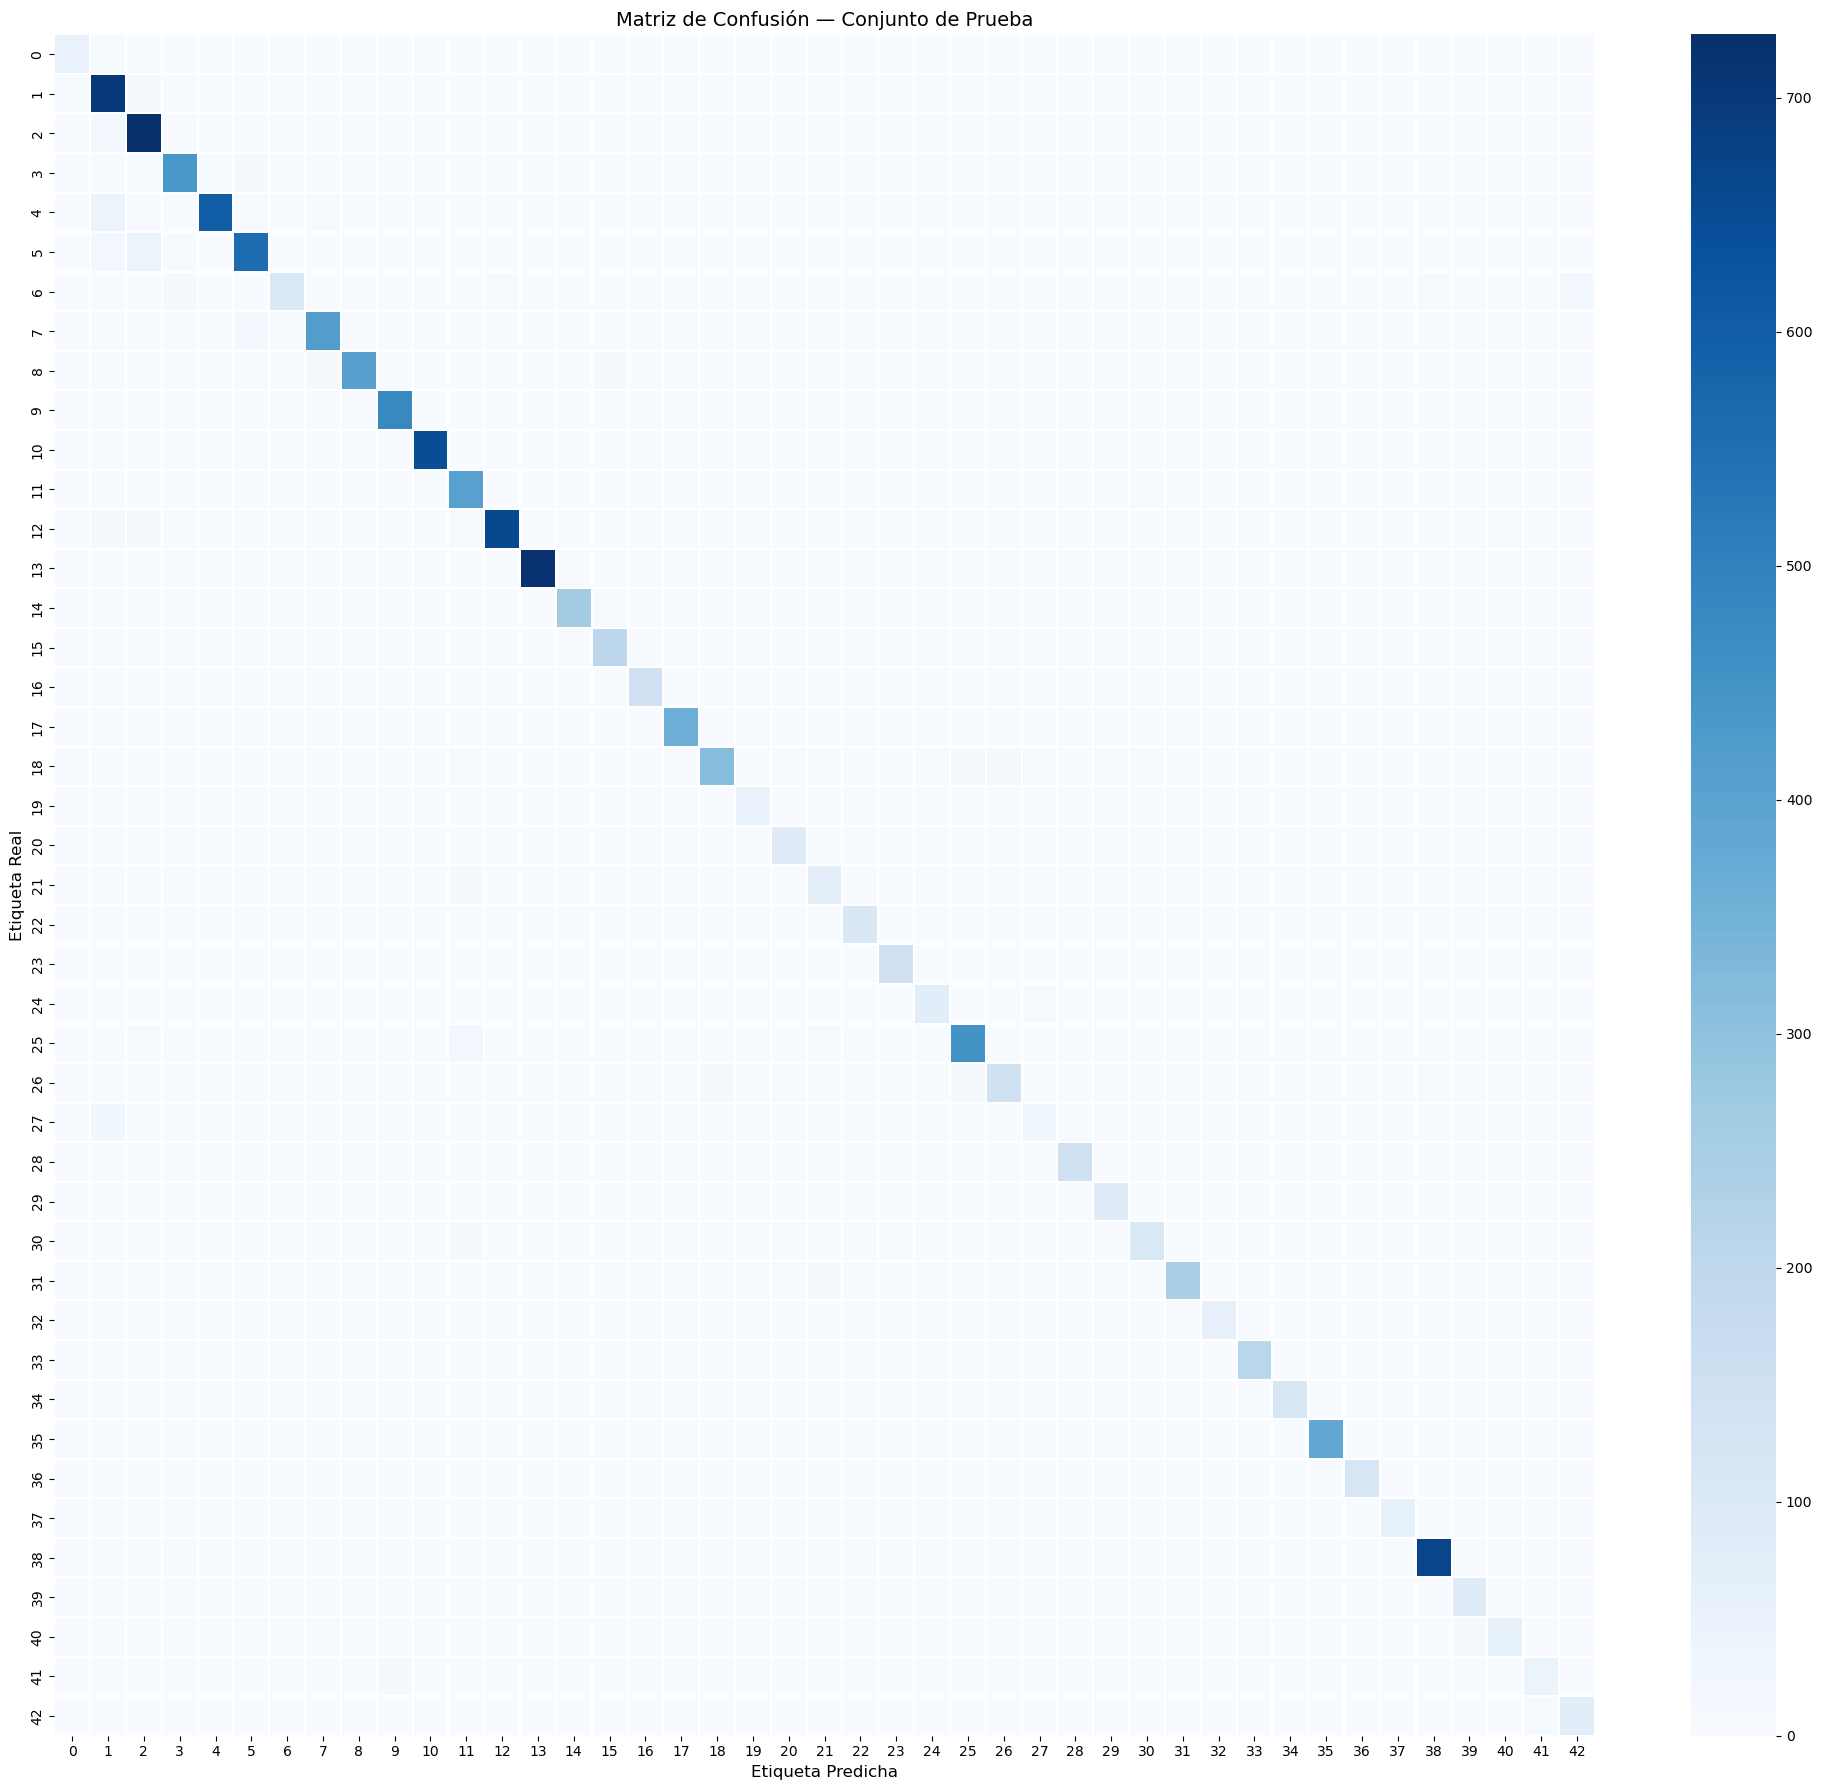

In [14]:
# Matriz de confusión 43×43
cm = confusion_matrix(y_test_raw, y_pred)

plt.figure(figsize=(20, 18))
sns.heatmap(
    cm, annot=False, cmap='Blues',
    xticklabels=range(NUM_CLASSES),
    yticklabels=range(NUM_CLASSES),
    linewidths=0.3
)
plt.title('Matriz de Confusión — Conjunto de Prueba', fontsize=14)
plt.ylabel('Etiqueta Real',     fontsize=12)
plt.xlabel('Etiqueta Predicha', fontsize=12)
plt.tight_layout()
plt.show()

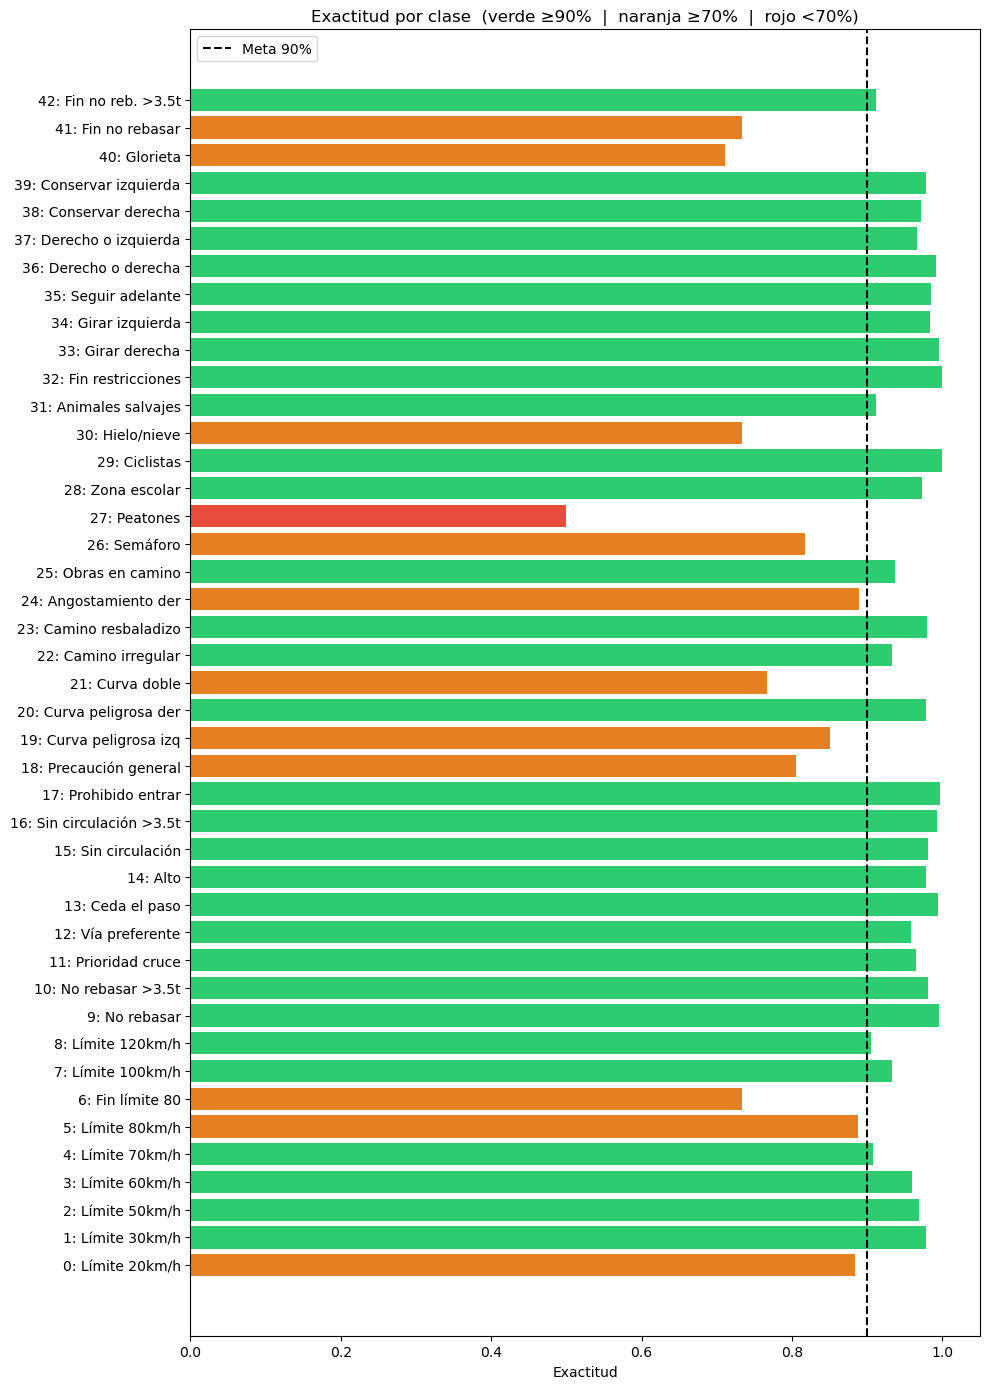

Clases con exactitud ≥90%:  31/43
Exactitud promedio por clase: 91.39%


In [15]:
# Exactitud por clase
class_acc = cm.diagonal() / cm.sum(axis=1)
colors = ['#2ecc71' if a >= 0.9 else '#e67e22' if a >= 0.7 else '#e74c3c' for a in class_acc]

plt.figure(figsize=(10, 14))
plt.barh(
    [f'{i}: {class_names[i][:22]}' for i in range(NUM_CLASSES)],
    class_acc,
    color=colors
)
plt.axvline(x=0.9, color='black', linestyle='--', linewidth=1.5, label='Meta 90%')
plt.xlabel('Exactitud')
plt.title('Exactitud por clase  (verde ≥90%  |  naranja ≥70%  |  rojo <70%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Clases con exactitud ≥90%:  {sum(class_acc >= 0.9)}/{NUM_CLASSES}")
print(f"Exactitud promedio por clase: {class_acc.mean() * 100:.2f}%")

### Interpretación de exactitud por clase
- Las clases con **mayor número de imágenes de entrenamiento** (límites de velocidad, ceda el paso, alto) tienden a tener exactitud ≥90% por el mayor volumen de ejemplos disponibles.
- Las clases con **menor representación** en el dataset o con apariencia visual similar entre sí (por ejemplo señales de fin de restricción vs. fin de no rebasar) son las más propensas a errores de clasificación.
- La gráfica permite identificar rápidamente qué clases requieren atención adicional (color rojo o naranja) para futuras mejoras como aumento de datos focalizado o ajuste de pesos por clase.

# Ejemplos de predicción

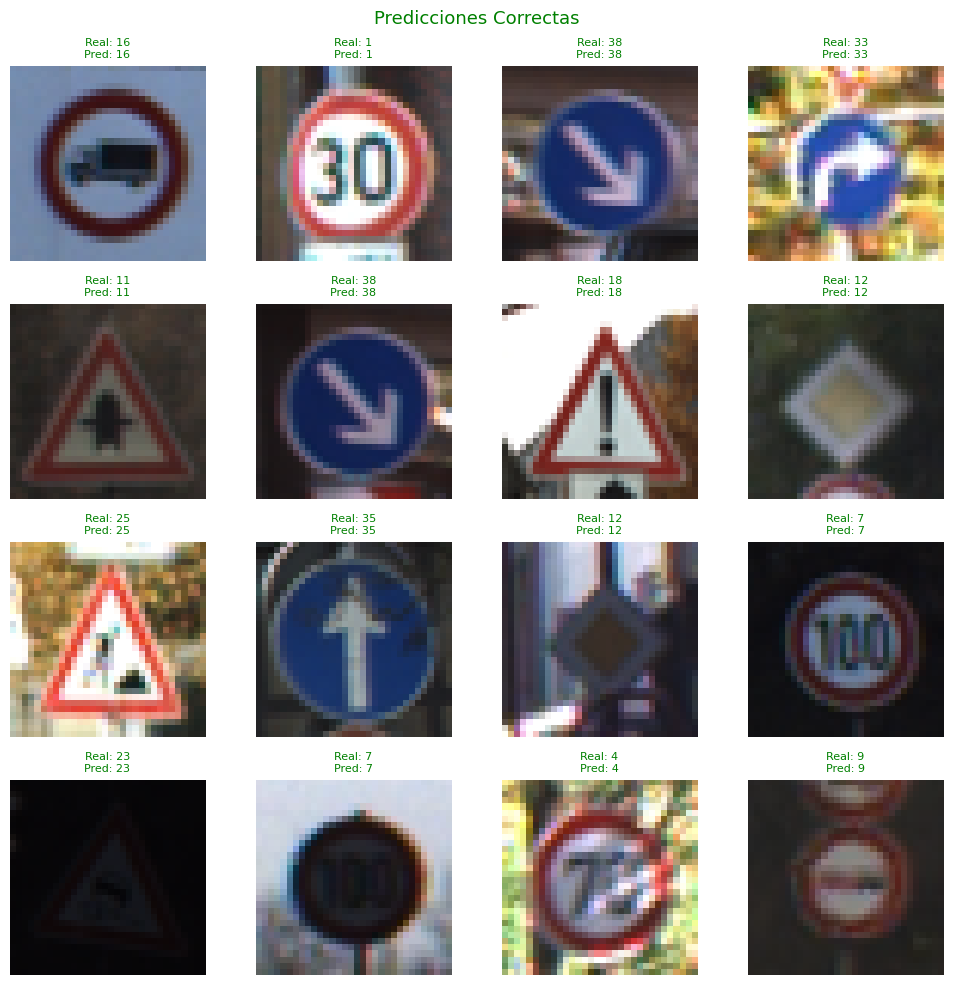

In [16]:
# Predicciones correctas
correct_idx = np.where(y_pred == y_test_raw)[0][:16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, idx in enumerate(correct_idx):
    axes[i // 4, i % 4].imshow(X_test[idx])
    axes[i // 4, i % 4].set_title(
        f'Real: {y_test_raw[idx]}\nPred: {y_pred[idx]}',
        color='green', fontsize=8
    )
    axes[i // 4, i % 4].axis('off')
plt.suptitle('Predicciones Correctas', fontsize=13, color='green')
plt.tight_layout()
plt.show()

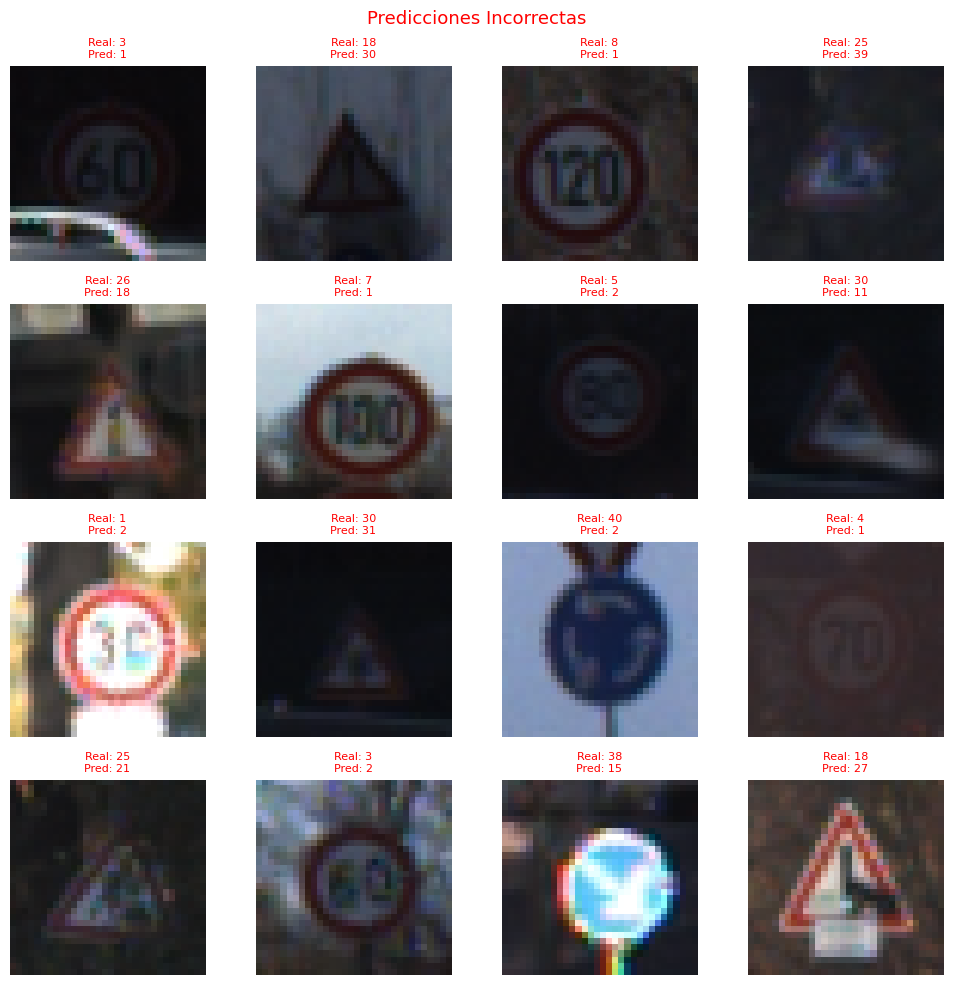

In [17]:
# Predicciones incorrectas
wrong_idx = np.where(y_pred != y_test_raw)[0][:16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, idx in enumerate(wrong_idx):
    axes[i // 4, i % 4].imshow(X_test[idx])
    axes[i // 4, i % 4].set_title(
        f'Real: {y_test_raw[idx]}\nPred: {y_pred[idx]}',
        color='red', fontsize=8
    )
    axes[i // 4, i % 4].axis('off')
plt.suptitle('Predicciones Incorrectas', fontsize=13, color='red')
plt.tight_layout()
plt.show()

# Conclusión

El modelo CNN basado en la arquitectura NVIDIA, adaptado para clasificación multiclase, demostró ser efectivo para el reconocimiento de señales de tráfico del dataset GTSRB:

- Se entrenó sobre **39,209 imágenes** de 43 clases en tan solo **15 épocas**, alcanzando una exactitud de **98.8% en validación** y **94.8% en el conjunto de prueba**.
- La arquitectura convolucional con strides progresivos permitió extraer características visuales relevantes (bordes, formas, colores) de forma eficiente sin necesidad de MaxPooling explícito.
- El uso de **Dropout(0.5)** entre las capas densas fue suficiente para mantener la brecha train/val acotada durante el entrenamiento.
- La diferencia entre validación y prueba (~4%) se atribuye a las condiciones más variadas del conjunto de prueba del GTSRB, y no a un fallo del modelo.

# Exportación del modelo entrenado

In [18]:
model.save('gtsrb_model.keras')
print("Modelo guardado: gtsrb_model.keras")

Modelo guardado: gtsrb_model.keras


In [ ]:
# ONNX (Open Neural Network Exchange) se usó como formato intermedio porque TensorFlow no puede cargarse dentro 
# del proceso de Webots en macOS — el backend Metal de GPU causa un crash de mutex al momento del fork. 
# ONNX Runtime es una librería de inferencia independiente de TensorFlow que ejecuta el modelo en CPU sin ese conflicto, 
# permitiendo usar el modelo entrenado directamente sin reimplementar su lógica.

import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'tf2onnx', 'onnxruntime', '-q'])

result = subprocess.run([
    sys.executable, '-m', 'tf2onnx.convert',
    '--keras', 'gtsrb_model.h5',
    '--output', 'gtsrb_model.onnx',
    '--opset', '13'
], capture_output=True, text=True)

print(result.stdout)
print(result.stderr)


2026-06-07 07:29:57,455 - WARNING - Compiled the loaded model, but the compiled metrics have yet to be built. `model.compile_metrics` will be empty until you train or evaluate the model.
2026-06-07 07:29:57.510325: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-06-07 07:29:57.510379: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-06-07 07:29:57.591120: I tensorflow/core/grappler/devices.cc:75] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0 (Note: TensorFlow was not compiled with CUDA or ROCm support)
2026-06-07 07:29:57.591165: I tensorflow/core/grappler/clusters/single_machine.cc:361] Starting new session
2026-06-07 07:29:57,637 - INFO - Using tensorflow=2.16.2, onnx=1.21.0, tf2onnx=1.17.0/None
2026-06-07 07:29:57,637 - INFO - Using opset <onnx, 13>
2026-06-07 07:29:57,652 - INFO - Computed